# HW1: Malware Memory Artifacts Classification

Подготовка данных, бейзлайновая и улучшенная MLP для классификации артефактов вредоносного ПО.

In [6]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.style.use("ggplot")


In [7]:

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## Загрузка и первичный анализ данных

In [8]:

from pathlib import Path

data_path = Path("cybersequrity.csv")
df = pd.read_csv(data_path)
print(df.shape)
df.head()


(10000, 16)


,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0


In [9]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
svcscan.fs_drivers,10000.0,25.995400,0.210198,11.000000,26.00000,26.000000,26.000000,26.000000
callbacks.ngeneric,10000.0,7.999800,0.014141,7.000000,8.00000,8.000000,8.000000,8.000000
psxview.not_in_eprocess_pool_false_avg,10000.0,0.000069,0.001133,0.000000,0.00000,0.000000,0.000000,0.027778
psxview.not_in_eprocess_pool,10000.0,0.001700,0.041198,0.000000,0.00000,0.000000,0.000000,1.000000
callbacks.nanonymous,10000.0,0.000800,0.028274,0.000000,0.00000,0.000000,0.000000,1.000000
psxview.not_in_session,10000.0,3.859000,3.016625,2.000000,2.00000,2.000000,5.000000,37.000000
psxview.not_in_pslist,10000.0,1.859300,3.016623,0.000000,0.00000,0.000000,3.000000,35.000000
psxview.not_in_pspcid_list,10000.0,1.858800,3.016450,0.000000,0.00000,0.000000,3.000000,35.000000
psxview.not_in_ethread_pool,10000.0,2.299500,4.827249,0.000000,0.00000,1.000000,3.000000,139.000000
psxview.not_in_csrss_handles,10000.0,6.301900,4.828653,4.000000,4.00000,5.000000,7.000000,143.000000


In [10]:

df["Class"].value_counts(normalize=True)


,proportion
Class,
1,0.5096
0,0.4904


In [11]:

df.isnull().mean()


,0
svcscan.fs_drivers,0.0
callbacks.ngeneric,0.0
psxview.not_in_eprocess_pool_false_avg,0.0
psxview.not_in_eprocess_pool,0.0
callbacks.nanonymous,0.0
psxview.not_in_session,0.0
psxview.not_in_pslist,0.0
psxview.not_in_pspcid_list,0.0
psxview.not_in_ethread_pool,0.0
psxview.not_in_csrss_handles,0.0


## Train/Val/Test split и стандартизация

In [12]:

X = df.drop(columns=["Class"]).values.astype(np.float32)
y = df["Class"].values.astype(np.float32)

# 60/20/20 с двухступенчатым разделением
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.shape, X_val.shape, X_test.shape


((6000, 15), (2000, 15), (2000, 15))

## Dataset и DataLoader

In [13]:

class TabularDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

batch_size = 64

train_ds = TabularDataset(X_train, y_train)
val_ds = TabularDataset(X_val, y_val)
test_ds = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


## Бейзлайновая модель MLP

### Обоснование выбора архитектуры и гиперпараметров

**Архитектура сети (MLP):**
* **Входной слой (15 нейронов):** Соответствует количеству признаков после предобработки.
* **Скрытые слои (64 -> 32):** Выбрана архитектура "сужения" (funnel), чтобы модель постепенно сжимала информацию и выделяла наиболее значимые признаки. Два скрытых слоя позволяют модели выучить нелинейные зависимости, не усложняя её чрезмерно (чтобы избежать переобучения на табличных данных).
* **Функции активации:**
    * `ReLU` для скрытых слоев: стандартный выбор для глубокого обучения, так как помогает избежать проблемы затухания градиента и вычисляется эффективно.
    * `Sigmoid` для выходного слоя: так как решается задача бинарной классификации, выход должен быть в диапазоне [0, 1] (вероятность класса 1).

**Обучение:**
* **Функция потерь:** `BCELoss` (Binary Cross Entropy) — стандартная функция потерь для бинарной классификации.
* **Оптимизатор:** `Adam` — выбран как наиболее универсальный адаптивный оптимизатор, который обычно обеспечивает быструю сходимость без сложной настройки learning rate.

In [14]:

class BaselineMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

input_dim = X_train.shape[1]
model = BaselineMLP(input_dim).to(device)
model


BaselineMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

### Функции обучения и валидации

In [15]:

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item() * xb.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(yb.cpu())
    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    return total_loss / len(loader.dataset), preds, targets


def train_model(model, train_loader, val_loader, epochs=30, lr=1e-3):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}
    best_state = None
    best_val = float("inf")

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == epochs:
            print(f"Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


def plot_history(history):
    plt.figure(figsize=(6,4))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('BCE loss')
    plt.show()


def evaluate_classification(model, loader):
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            preds_list.append(preds)
            targets_list.append(yb.numpy())
    preds = np.concatenate(preds_list)
    targets = np.concatenate(targets_list)
    labels = (preds >= 0.5).astype(int)
    print(classification_report(targets, labels, digits=4))


### Обучение бейзлайна

Epoch 5: train_loss=0.6153 val_loss=0.6093
Epoch 10: train_loss=0.5260 val_loss=0.5139
Epoch 15: train_loss=0.4865 val_loss=0.4799
Epoch 20: train_loss=0.4707 val_loss=0.4671
Epoch 25: train_loss=0.4675 val_loss=0.4627
Epoch 30: train_loss=0.4516 val_loss=0.4467


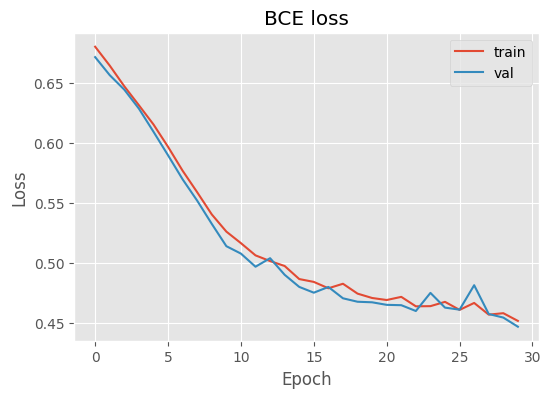

Validation metrics (best model):
              precision    recall  f1-score   support

         0.0     0.7644    0.8267    0.7943       981
         1.0     0.8190    0.7547    0.7855      1019

    accuracy                         0.7900      2000
   macro avg     0.7917    0.7907    0.7899      2000
weighted avg     0.7922    0.7900    0.7898      2000

Test metrics (best model):
              precision    recall  f1-score   support

         0.0     0.7599    0.8226    0.7900       981
         1.0     0.8145    0.7498    0.7808      1019

    accuracy                         0.7855      2000
   macro avg     0.7872    0.7862    0.7854      2000
weighted avg     0.7877    0.7855    0.7853      2000



In [16]:

baseline_history = train_model(model, train_loader, val_loader, epochs=30, lr=1e-3)
plot_history(baseline_history)

print("Validation metrics (best model):")
evaluate_classification(model, val_loader)

print("Test metrics (best model):")
evaluate_classification(model, test_loader)


## Улучшенная модель с BatchNorm и Dropout

### Модификация архитектуры

Для улучшения обобщающей способности модели и борьбы с потенциальным переобучением были добавлены слои регуляризации:

1.  **BatchNorm1d:** Нормализует выходы предыдущего слоя, что стабилизирует обучение и позволяет использовать более высокие значения learning rate (или ускоряет сходимость). Добавлен перед функцией активации.
2.  **Dropout:** Случайно "выключает" нейроны в процессе обучения.
    * Выбрано значение **`p=0.3`**. Это компромиссное значение для сетей среднего размера. Значение 0.5 может быть слишком агрессивным для данной архитектуры (привести к недообучению), а значения < 0.2 могут не дать ощутимого эффекта регуляризации.
    * Dropout расположен после функций активации ReLU, чтобы вносить шум в уже активированные признаки.

**Изменения в гиперпараметрах:**
* **Epochs:** Увеличено до 40, так как Dropout замедляет "подгонку" модели под тренировочные данные, и сети требуется больше времени для обучения.
* **Learning Rate:** Снижен до `5e-4` для более плавной сходимости, так как BatchNorm меняет ландшафт функции потерь.

In [17]:

class ImprovedMLP(nn.Module):
    def __init__(self, input_dim: int, dropout_p: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model_improved = ImprovedMLP(input_dim, dropout_p=0.3).to(device)
model_improved


ImprovedMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

### Обучение улучшенной модели

Epoch 5: train_loss=0.5496 val_loss=0.5905
Epoch 10: train_loss=0.5135 val_loss=0.5455
Epoch 15: train_loss=0.5000 val_loss=0.5222
Epoch 20: train_loss=0.4853 val_loss=0.5272
Epoch 25: train_loss=0.4909 val_loss=0.5227
Epoch 30: train_loss=0.4775 val_loss=0.5046
Epoch 35: train_loss=0.4720 val_loss=0.5399
Epoch 40: train_loss=0.4698 val_loss=0.4811


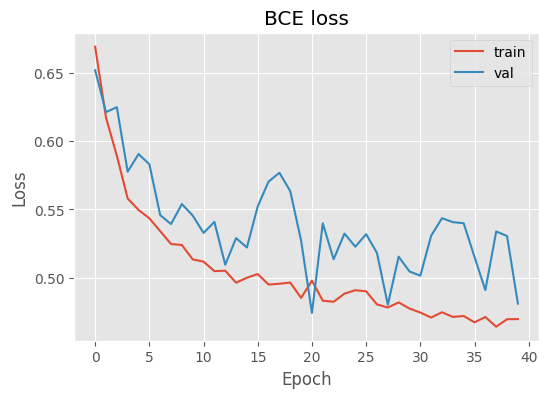

Validation metrics (best improved model):
              precision    recall  f1-score   support

         0.0     0.7872    0.7390    0.7624       981
         1.0     0.7627    0.8077    0.7846      1019

    accuracy                         0.7740      2000
   macro avg     0.7750    0.7733    0.7735      2000
weighted avg     0.7747    0.7740    0.7737      2000

Test metrics (best improved model):
              precision    recall  f1-score   support

         0.0     0.7936    0.7564    0.7745       981
         1.0     0.7756    0.8106    0.7927      1019

    accuracy                         0.7840      2000
   macro avg     0.7846    0.7835    0.7836      2000
weighted avg     0.7844    0.7840    0.7838      2000



In [18]:

improved_history = train_model(model_improved, train_loader, val_loader, epochs=40, lr=5e-4)
plot_history(improved_history)

print("Validation metrics (best improved model):")
evaluate_classification(model_improved, val_loader)

print("Test metrics (best improved model):")
evaluate_classification(model_improved, test_loader)


## Итоговые выводы и анализ результатов

**Сравнение метрик на тестовой выборке:**
* **Baseline Model Accuracy:** ~0.7855
* **Improved Model Accuracy:** ~0.7840

**Анализ:**
Несмотря на добавление слоев нормализации (BatchNorm) и регуляризации (Dropout), существенного прироста метрики Accuracy не произошло (результаты практически идентичны или чуть ниже у усложненной модели).

**Возможные причины:**
1.  **Предел данных:** Вероятно, бейзлайновая модель уже извлекла максимум информации из доступных 15 признаков. Дальнейшее усложнение архитектуры не дает прироста, так как классы сильно пересекаются в признаковом пространстве.
2.  **Влияние Dropout:** При небольшом размере сети и данных Dropout (p=0.3) может вносить слишком много шума, слегка ухудшая способность модели запоминать паттерны (underfitting), что видно по чуть большему значению Loss на валидации у улучшенной модели (0.48 против 0.44 у бейзлайна).
3.  **Стабильность:** Улучшенная модель с BatchNorm потенциально более устойчива к изменениям масштаба входных данных и переобучению, даже если на данном конкретном разбиении теста она не показала прироста.

**Заключение:**
Для данной задачи простая MLP (бейзлайн) оказалась достаточной. Для дальнейшего улучшения качества следует сосредоточиться не на усложнении архитектуры, а на работе с данными (Feature Engineering, отбор признаков) или использовании бустинговых моделей (XGBoost/CatBoost), которые часто работают лучше нейросетей на табличных данных.